# FIFA World Cup 2026 — Player & Squad Analytics

**Goal of this notebook**
1. Import & inspect the raw dataset (structure, dtypes, missingness)
2. Clean the data **without deleting rows** — only 100%-empty columns are dropped,
   missing values are filled based on *why* they are missing (never guessed)
3. Detect outliers (flag, don't delete) and run full descriptive/EDA analysis
4. Unsupervised learning: K-Means clustering + PCA
5. Association Rule Mining (Apriori) on player performance profiles
6. Supervised learning: Logistic Regression, Decision Tree, Random Forest,
   Gradient Boosting (GBRT), KNN, SVM — baseline 80/20 split
7. Model evaluation: Accuracy (train/test), Precision, Recall, F1, ROC-AUC,
   Confusion Matrices, and one combined ROC chart
8. Hyperparameter tuning: GridSearchCV, 5-fold CV, re-evaluate all models
9. Final model comparison & key insights

> **Run this in Google Colab**: Runtime → Run all. If a package is missing,
> the first cell installs everything needed.

In [1]:
# If running in Google Colab, uncomment the line below to install dependencies
!pip install -q ftfy mlxtend scikit-learn==1.8.0 plotly

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ftfy

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## 1. Import the raw dataset

In Colab: upload `fifa_wc2026_raw.csv` via the file browser (left sidebar),
or mount Google Drive. Update `RAW_PATH` accordingly.

In [2]:
RAW_PATH = "fifa_wc2026_raw.csv"   # <-- change if needed (Colab: /content/fifa_wc2026_raw.csv)
try:
    df_raw = pd.read_csv(RAW_PATH)
except FileNotFoundError:
    # fallback for local repo structure
    df_raw = pd.read_csv("../raw_parsed.csv")

print("Shape:", df_raw.shape)
df_raw.head()

Shape: (1248, 35)


,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,goals,position_stat,matches_played,matches_started,minutes_played,goals_stat,assists,shots,shots_on_target,yellow_cards,red_cards,penalty_goals,own_goals,clean_sheets,saves,goals_conceded,average_rating,data_source,last_verified,team_name,fifa_code,group_letter,confederation,fifa_ranking_pre_tournament,elo_rating,manager_name
0,1,1,JosÃ© RaÃºl Rangel,GK,CD Guadalajara,8933646,15,25-02-2000,190,0,GK,5,5,438,0,0,NaN,NaN,0,0,0,0,4.0,7.0,3.0,NaN,sofascore.com,19-07-2026,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
1,2,1,Jorge Eduardo Sanchez,DEF,PAOK Saloniki,24628639,59,10-12-1997,176,3,DEF,4,4,349,0,1,NaN,NaN,1,0,0,0,NaN,NaN,NaN,NaN,sofascore.com,19-07-2026,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
2,3,1,CÃ©sar Jasib Montes,DEF,FC Lokomotiv Moscow,10912552,69,24-02-1997,191,4,DEF,4,4,315,0,0,NaN,NaN,0,1,0,0,NaN,NaN,NaN,NaN,sofascore.com,19-07-2026,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
3,4,1,Edson Omar Alvarez,DEF,FenerbahÃ§e SK,10875943,100,24-10-1997,180,7,DEF,4,2,239,0,0,NaN,NaN,1,0,0,0,NaN,NaN,NaN,NaN,sofascore.com,19-07-2026,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
4,5,1,Johan Felipe Vasquez,DEF,Genoa CFC,18265363,47,22-10-1998,182,3,DEF,4,4,360,0,0,NaN,NaN,1,0,0,0,NaN,NaN,NaN,NaN,sofascore.com,19-07-2026,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   player_id                    1248 non-null   int64  
 1   team_id                      1248 non-null   int64  
 2   player_name                  1248 non-null   str    
 3   position                     1248 non-null   str    
 4   club_team                    1248 non-null   str    
 5   market_value_eur             1248 non-null   int64  
 6   caps                         1248 non-null   int64  
 7   date_of_birth                1248 non-null   str    
 8   height_cm                    1248 non-null   int64  
 9   goals                        1248 non-null   int64  
 10  position_stat                1248 non-null   str    
 11  matches_played               1248 non-null   int64  
 12  matches_started              1248 non-null   int64  
 13  minutes_played               

In [4]:
print("Missing values per column:")
print(df_raw.isna().sum().sort_values(ascending=False))

Missing values per column:
average_rating                 1248
shots_on_target                1248
shots                          1248
goals_conceded                 1103
saves                          1103
clean_sheets                   1103
data_source                     213
player_name                       0
team_id                           0
player_id                         0
position                          0
position_stat                     0
goals                             0
matches_played                    0
club_team                         0
date_of_birth                     0
height_cm                         0
market_value_eur                  0
caps                              0
yellow_cards                      0
assists                           0
minutes_played                    0
goals_stat                        0
matches_started                   0
own_goals                         0
red_cards                         0
penalty_goals                     0
l

### Observations from the raw import
- 1,248 players across 48 national squads (2026 FIFA World Cup, 48-team format)
- `shots`, `shots_on_target`, `average_rating` are **100% empty** — the data source
  never populated them for this tournament snapshot; they carry zero information
  and will be dropped (columns only, no rows removed).
- `clean_sheets`, `saves`, `goals_conceded` are only populated for goalkeepers —
  this is a **structural** missingness (not applicable to outfield players), so
  it is safe to fill with 0 rather than drop anything.
- `data_source` has some gaps — purely a metadata field, filled with an explicit
  "Unverified/Unknown" label so we never fabricate a source.

## 2. Data Cleaning (no rows removed)

In [5]:
def fix_encoding(series: pd.Series) -> pd.Series:
    """Repairs UTF-8-read-as-Latin-1 mojibake, e.g. 'JosÃ©' -> 'José'."""
    return series.astype(str).apply(lambda x: ftfy.fix_text(x) if x not in ("nan", "None") else x)

df = df_raw.copy()
n_start = len(df)

# --- fix text encoding ---
for c in ["player_name", "club_team", "team_name", "manager_name"]:
    df[c] = fix_encoding(df[c])

# --- correct dtypes ---
int_like = ["market_value_eur","caps","height_cm","goals","matches_played","matches_started",
            "minutes_played","goals_stat","assists","yellow_cards","red_cards","penalty_goals",
            "own_goals","fifa_ranking_pre_tournament","elo_rating"]
for c in int_like:
    df[c] = pd.to_numeric(df[c], errors="coerce")
for c in ["clean_sheets", "saves", "goals_conceded"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["date_of_birth"] = pd.to_datetime(df["date_of_birth"], format="%d-%m-%Y", errors="coerce")
df["last_verified"] = pd.to_datetime(df["last_verified"], format="%d-%m-%Y", errors="coerce")

# --- drop 100%-empty columns only ---
empty_cols = [c for c in df.columns if df[c].isna().mean() == 1.0]
df = df.drop(columns=empty_cols)
print("Dropped (100% empty):", empty_cols)

# --- structural missing-value fills (no row loss) ---
for c in ["clean_sheets", "saves", "goals_conceded"]:
    df[c] = df[c].fillna(0)
df["data_source"] = df["data_source"].fillna("Unverified/Unknown")

# --- resolve duplicate/redundant columns ---
df = df.rename(columns={"goals": "career_goals", "goals_stat": "tournament_goals",
                         "position_stat": "position_check"})
print("position vs position_check mismatches:", (df["position"] != df["position_check"]).sum())
df = df.drop(columns=["position_check"])

assert len(df) == n_start, "Row count must not change!"
print(f"\nRows preserved: {len(df)} / {n_start}  ✔")
df.head()

Dropped (100% empty): ['shots', 'shots_on_target', 'average_rating']
position vs position_check mismatches: 0

Rows preserved: 1248 / 1248  ✔


,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,career_goals,matches_played,matches_started,minutes_played,tournament_goals,assists,yellow_cards,red_cards,penalty_goals,own_goals,clean_sheets,saves,goals_conceded,data_source,last_verified,team_name,fifa_code,group_letter,confederation,fifa_ranking_pre_tournament,elo_rating,manager_name
0,1,1,José Raúl Rangel,GK,CD Guadalajara,8933646,15,2000-02-25,190,0,5,5,438,0,0,0,0,0,0,4.0,7.0,3.0,sofascore.com,2026-07-19,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
1,2,1,Jorge Eduardo Sanchez,DEF,PAOK Saloniki,24628639,59,1997-12-10,176,3,4,4,349,0,1,1,0,0,0,0.0,0.0,0.0,sofascore.com,2026-07-19,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
2,3,1,César Jasib Montes,DEF,FC Lokomotiv Moscow,10912552,69,1997-02-24,191,4,4,4,315,0,0,0,1,0,0,0.0,0.0,0.0,sofascore.com,2026-07-19,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
3,4,1,Edson Omar Alvarez,DEF,Fenerbahçe SK,10875943,100,1997-10-24,180,7,4,2,239,0,0,1,0,0,0,0.0,0.0,0.0,sofascore.com,2026-07-19,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
4,5,1,Johan Felipe Vasquez,DEF,Genoa CFC,18265363,47,1998-10-22,182,3,4,4,360,0,0,1,0,0,0,0.0,0.0,0.0,sofascore.com,2026-07-19,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre


## 3. Outlier Detection (IQR method — flagged, never deleted)

Extreme values here (e.g. a €200M market value, 143 career goals) are **real,
legitimate values** for elite/veteran players, not data-entry errors — so they
are flagged for awareness and used carefully in modeling, but no rows are cut.

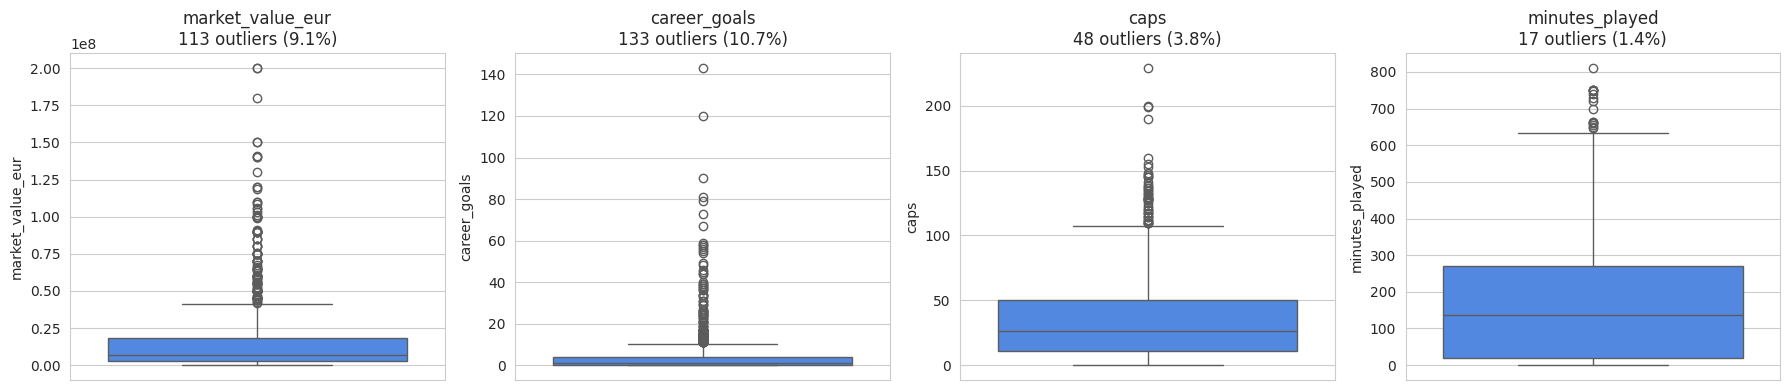

{'market_value_eur': 113, 'career_goals': 133, 'caps': 48, 'minutes_played': 17}


In [6]:
outlier_cols = ["market_value_eur", "career_goals", "caps", "minutes_played"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
outlier_summary = {}
for ax, c in zip(axes, outlier_cols):
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    flag = (df[c] < lo) | (df[c] > hi)
    df[f"{c}_is_outlier"] = flag
    outlier_summary[c] = int(flag.sum())
    sns.boxplot(y=df[c], ax=ax, color="#3B82F6")
    ax.set_title(f"{c}\n{flag.sum()} outliers ({flag.mean()*100:.1f}%)")
plt.tight_layout()
plt.savefig("outlier_boxplots.png", dpi=120)
plt.show()
print(outlier_summary)

In [7]:
# Winsorized (capped at 1st/99th pct) market value — used ONLY for distance-based
# models (KMeans/PCA) which are sensitive to extreme scale; raw column is kept for reporting.
p1, p99 = df["market_value_eur"].quantile([0.01, 0.99])
df["market_value_eur_capped"] = df["market_value_eur"].clip(p1, p99)

## 4. Feature Engineering

In [8]:
TOURNAMENT_START = pd.Timestamp("2026-06-11")

df["age_years"] = ((TOURNAMENT_START - df["date_of_birth"]).dt.days / 365.25).round(1)
df["start_rate"] = np.where(df["matches_played"] > 0, df["matches_started"] / df["matches_played"], 0)
df["minutes_per_match"] = np.where(df["matches_played"] > 0, df["minutes_played"] / df["matches_played"], 0)
df["goal_involvement"] = df["tournament_goals"] + df["assists"]
df["discipline_index"] = df["yellow_cards"] + 3 * df["red_cards"]
df["value_per_cap"] = df["market_value_eur"] / (df["caps"] + 1)
df["experience_tier"] = pd.cut(df["caps"], bins=[-1, 10, 30, 60, 1000],
                                labels=["Rookie(<=10)", "Developing(11-30)", "Established(31-60)", "Veteran(60+)"])
df["age_group"] = pd.cut(df["age_years"], bins=[0, 23, 27, 31, 50], labels=["U23", "24-27", "28-31", "32+"])

team_agg = df.groupby("team_name").agg(
    team_avg_market_value=("market_value_eur", "mean"),
    team_total_market_value=("market_value_eur", "sum"),
    team_avg_age=("age_years", "mean"),
    squad_size=("player_id", "count")
).reset_index()
df = df.merge(team_agg, on="team_name", how="left")

# --- Advanced per-90 / percentage KPIs (standard football analytics ratios) ---
# All are NaN (not a fabricated 0) when the denominator is 0 — "not applicable", not "zero rate".
def safe_div(numer, denom, scale=1):
    return np.where(denom > 0, (numer / denom) * scale, np.nan)

df["goals_per_90"] = safe_div(df["tournament_goals"], df["minutes_played"], 90)
df["assists_per_90"] = safe_div(df["assists"], df["minutes_played"], 90)
df["goal_contribution"] = df["tournament_goals"] + df["assists"]  # same definition as goal_involvement
df["goal_contribution_per_90"] = safe_div(df["goal_contribution"], df["minutes_played"], 90)
df["minutes_per_goal"] = safe_div(df["minutes_played"], df["tournament_goals"], 1)
df["save_percentage"] = safe_div(df["saves"], df["saves"] + df["goals_conceded"], 100)
df["clean_sheet_percentage"] = safe_div(df["clean_sheets"], df["matches_played"], 100)
df["start_percentage"] = safe_div(df["matches_started"], df["matches_played"], 100)
df["market_value_per_cap"] = df["value_per_cap"]  # alias, same formula (market_value / (caps+1) to avoid div/0)
df["goals_per_cap"] = safe_div(df["career_goals"], df["caps"], 1)
df["avg_minutes_per_match"] = df["minutes_per_match"]  # alias, same formula

# Classification target: elite (top-quartile) market value player
thresh = df["market_value_eur"].quantile(0.75)
df["is_high_value"] = (df["market_value_eur"] >= thresh).astype(int)
print("High-value threshold:", f"{thresh:,.0f} EUR")
print(df["is_high_value"].value_counts(normalize=True))

df.to_csv("fifa_wc2026_cleaned.csv", index=False)
print("\nFinal cleaned shape:", df.shape)

High-value threshold: 18,000,000 EUR
is_high_value
0    0.741987
1    0.258013
Name: proportion, dtype: float64

Final cleaned shape: (1248, 60)


### Advanced KPIs — quick look

| KPI | Formula |
|---|---|
| Goals per 90 | (Goals ÷ Minutes Played) × 90 |
| Assists per 90 | (Assists ÷ Minutes Played) × 90 |
| Goal Contribution | Goals + Assists |
| Goal Contribution per 90 | ((Goals + Assists) ÷ Minutes Played) × 90 |
| Minutes per Goal | Minutes Played ÷ Goals |
| Save Percentage | Saves ÷ (Saves + Goals Conceded) × 100 |
| Clean Sheet Percentage | Clean Sheets ÷ Matches Played × 100 |
| Start Percentage | Matches Started ÷ Matches Played × 100 |
| Market Value per Cap | Market Value ÷ Caps |
| Goals per Cap | Goals ÷ Caps |
| Average Minutes per Match | Minutes Played ÷ Matches Played |

All are computed on **tournament** goals/assists (not career totals) except
`goals_per_cap`, which uses career goals to pair naturally with career caps.
Ratios are left as `NaN` (not 0) when the denominator is 0 — a player with 0
minutes has an undefined per-90 rate, not a zero rate.

In [9]:
kpi_cols = ["player_name","team_name","position","minutes_played","tournament_goals","assists",
            "goals_per_90","assists_per_90","goal_contribution_per_90","minutes_per_goal",
            "save_percentage","clean_sheet_percentage","start_percentage",
            "market_value_per_cap","goals_per_cap","avg_minutes_per_match"]

print("Top 10 by Goal Contribution per 90 (min. 180 minutes played):")
df[df["minutes_played"] >= 180].nlargest(10, "goal_contribution_per_90")[kpi_cols[:9]].round(2)

Top 10 by Goal Contribution per 90 (min. 180 minutes played):


,player_name,team_name,position,minutes_played,tournament_goals,assists,goals_per_90,assists_per_90,goal_contribution_per_90
190,Johan Kula Manzambi,Switzerland,MID,198,3,2,1.36,0.91,2.27
841,Kylian Mbappe,France,FWD,698,10,4,1.29,0.52,1.81
1150,Bukayo Ayoyinka Saka,England,FWD,358,3,3,0.75,0.75,1.51
945,Lionel Andrés Messi,Argentina,FWD,740,8,4,0.97,0.49,1.46
543,Crysencio Jilbert Sylverio Cir Summerville,Netherlands,FWD,252,2,2,0.71,0.71,1.43
918,Erling Braut Haaland,Norway,FWD,465,7,0,1.35,0.00,1.35
968,Riyad Karim Mahrez,Algeria,FWD,282,2,2,0.64,0.64,1.28
875,Ismaila Sarr,Senegal,FWD,366,4,1,0.98,0.25,1.23
838,Masour Ousmane Dembele,France,FWD,513,6,1,1.05,0.18,1.23
538,Brian Ebenezer Adjei Brobbey,Netherlands,FWD,225,3,0,1.20,0.00,1.20


In [10]:
print("Top 10 Goalkeepers by Save Percentage (min. 3 matches played):")
gk = df[(df["position"] == "GK") & (df["matches_played"] >= 3)]
gk.nlargest(10, "save_percentage")[["player_name","team_name","matches_played","saves","goals_conceded",
                                      "save_percentage","clean_sheet_percentage"]].round(2)

Top 10 Goalkeepers by Save Percentage (min. 3 matches played):


,player_name,team_name,matches_played,saves,goals_conceded,save_percentage,clean_sheet_percentage
750,Unai Simon,Spain,8,16.0,1.0,94.12,87.50
1129,Camilo Andres Vargas,Colombia,5,9.0,1.0,90.00,80.00
1040,Diogo Diogo Costa,Portugal,5,23.0,3.0,88.46,40.00
494,Hernán Ismael Galindez,Ecuador,4,25.0,4.0,86.21,25.00
676,Ali Reza Beiranvand,IR Iran,3,16.0,3.0,84.21,33.33
349,Orlando Daniel Gill,Paraguay,5,29.0,6.0,82.86,40.00
754,José Vozinha,Cabo Verde,4,23.0,5.0,82.14,50.00
26,Ronwen Hayden Williams,South Africa,4,17.0,4.0,80.95,25.00
381,Patrick Thomas Beach,Australia,4,11.0,3.0,78.57,50.00
800,Khalil Mohammed Alowais,Saudi Arabia,3,18.0,5.0,78.26,33.33


## 5. Descriptive Statistics

In [11]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
player_id,1248.0,6.245000e+02,3.604109e+02,1.000000e+00,3.127500e+02,6.245000e+02,9.362500e+02,1.248000e+03
team_id,1248.0,2.450000e+01,1.385895e+01,1.000000e+00,1.275000e+01,2.450000e+01,3.625000e+01,4.800000e+01
market_value_eur,1248.0,1.548747e+07,2.345332e+07,2.500000e+04,2.605922e+06,6.537974e+06,1.800000e+07,2.000000e+08
caps,1248.0,3.499119e+01,3.223123e+01,0.000000e+00,1.100000e+01,2.600000e+01,5.000000e+01,2.290000e+02
height_cm,1248.0,1.827756e+02,6.831644e+00,1.600000e+02,1.780000e+02,1.830000e+02,1.880000e+02,2.050000e+02
career_goals,1248.0,4.523237e+00,1.039722e+01,0.000000e+00,0.000000e+00,1.000000e+00,4.000000e+00,1.430000e+02
matches_played,1248.0,2.616987e+00,1.908265e+00,0.000000e+00,1.000000e+00,3.000000e+00,4.000000e+00,8.000000e+00
matches_started,1248.0,1.833333e+00,1.876571e+00,0.000000e+00,0.000000e+00,1.000000e+00,3.000000e+00,8.000000e+00
minutes_played,1248.0,1.697572e+02,1.627258e+02,0.000000e+00,2.000000e+01,1.360000e+02,2.700000e+02,8.100000e+02
tournament_goals,1248.0,2.379808e-01,7.694652e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+01


In [12]:
df.describe(include=["object", "category"]).T

,count,unique,top,freq
player_name,1248,1241,Mc,7
position,1248,4,DEF,421
club_team,1248,450,Manchester City FC,19
data_source,1248,2,sofascore.com,1035
team_name,1248,48,Mexico,26
fifa_code,1248,48,MEX,26
group_letter,1248,12,A,104
confederation,1248,6,UEFA,416
manager_name,1248,48,Javier Aguirre,26
experience_tier,1248,4,Developing(11-30),405


## 6. Exploratory Data Analysis

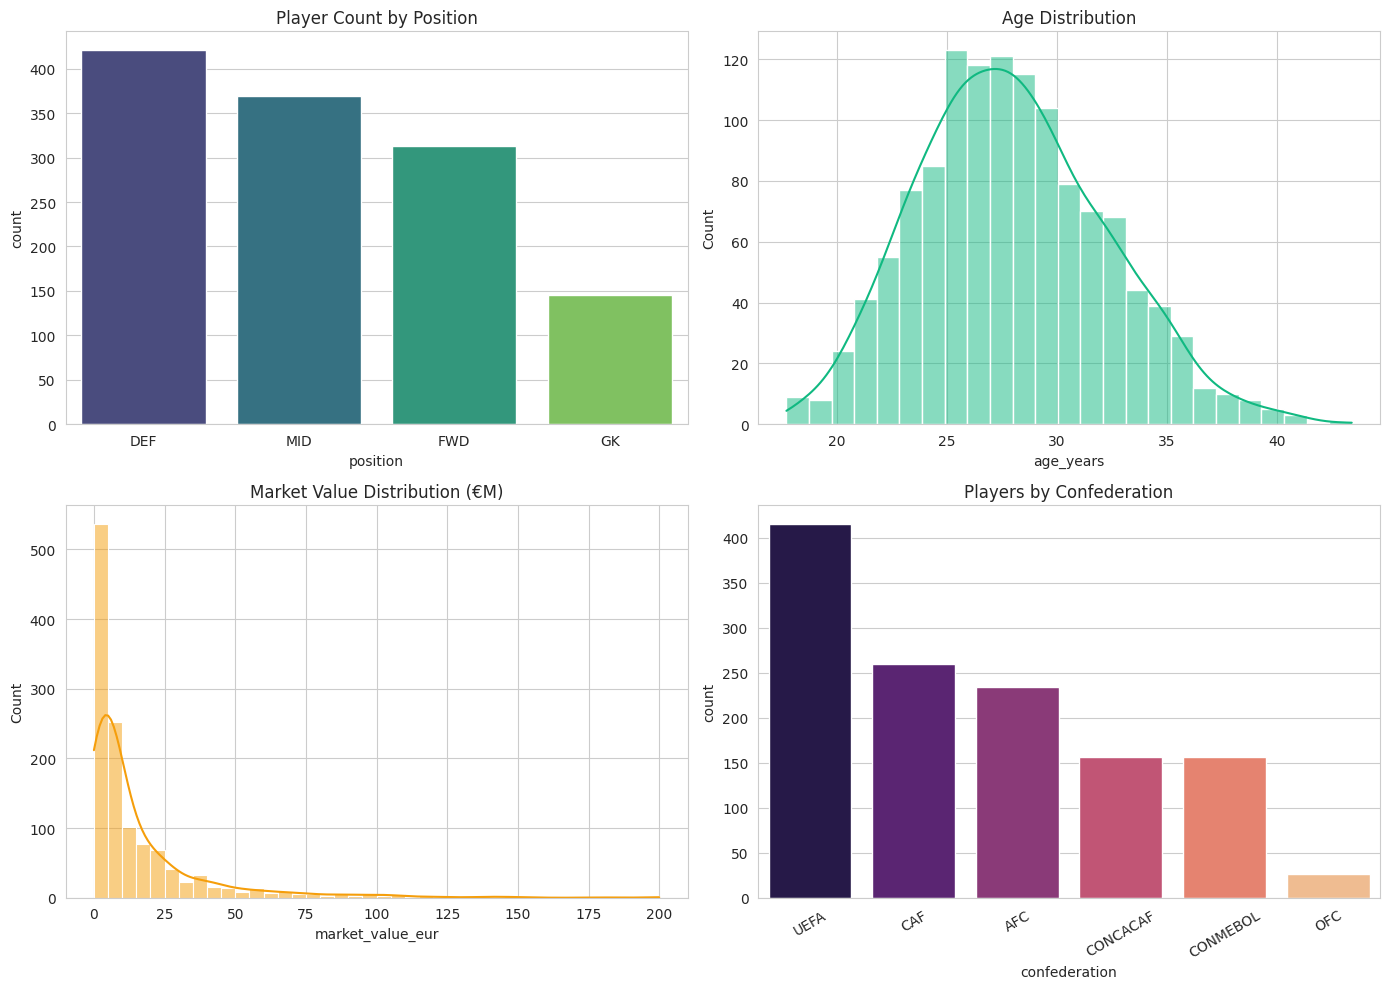

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(data=df, x="position", order=df.position.value_counts().index, ax=axes[0,0], palette="viridis")
axes[0,0].set_title("Player Count by Position")
sns.histplot(df["age_years"], bins=25, kde=True, ax=axes[0,1], color="#10B981")
axes[0,1].set_title("Age Distribution")
sns.histplot(df["market_value_eur"]/1e6, bins=40, kde=True, ax=axes[1,0], color="#F59E0B")
axes[1,0].set_title("Market Value Distribution (€M)")
sns.countplot(data=df, x="confederation", order=df.confederation.value_counts().index, ax=axes[1,1], palette="magma")
axes[1,1].set_title("Players by Confederation")
axes[1,1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("eda_overview.png", dpi=120)
plt.show()

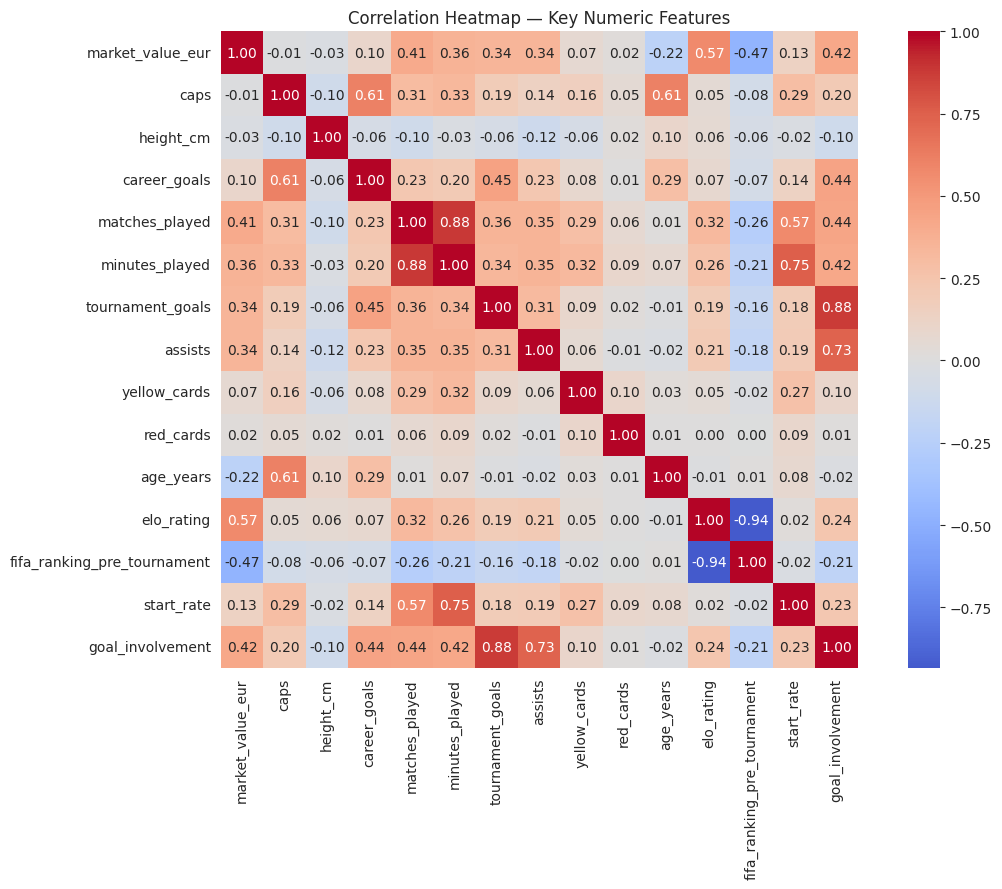

In [14]:
plt.figure(figsize=(12, 9))
num_cols_corr = ["market_value_eur","caps","height_cm","career_goals","matches_played","minutes_played",
                  "tournament_goals","assists","yellow_cards","red_cards","age_years","elo_rating",
                  "fifa_ranking_pre_tournament","start_rate","goal_involvement"]
corr = df[num_cols_corr].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap — Key Numeric Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120)
plt.show()

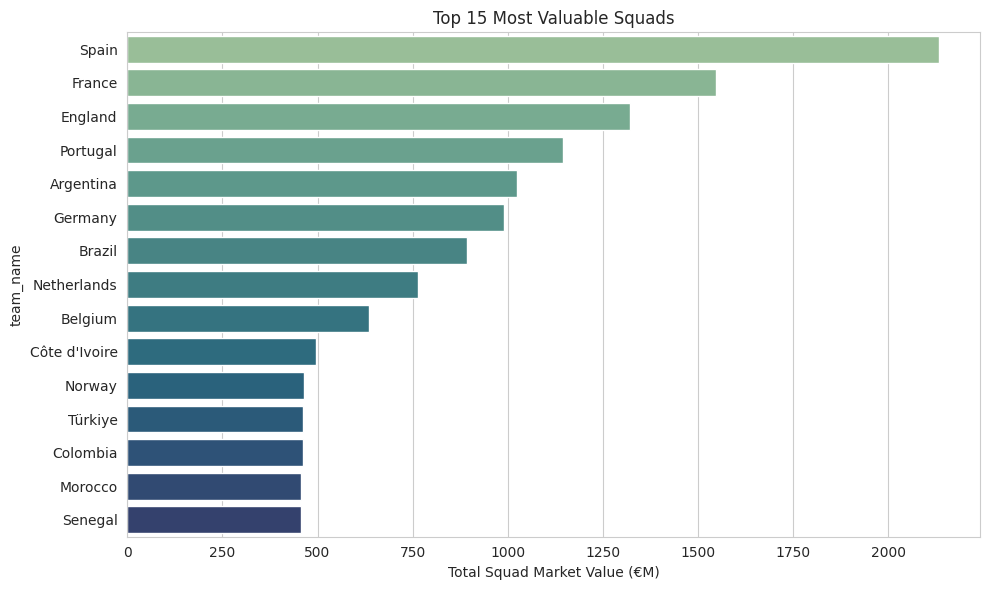

In [15]:
top_teams = df.groupby("team_name")["market_value_eur"].sum().sort_values(ascending=False).head(15)/1e6
plt.figure(figsize=(10,6))
sns.barplot(x=top_teams.values, y=top_teams.index, palette="crest")
plt.xlabel("Total Squad Market Value (€M)")
plt.title("Top 15 Most Valuable Squads")
plt.tight_layout()
plt.savefig("top_teams_value.png", dpi=120)
plt.show()

## 7. Unsupervised Learning — K-Means Clustering + PCA

We cluster players on their **performance/profile footprint** to discover
natural player archetypes (e.g. "elite attacking talent", "defensive workhorse").

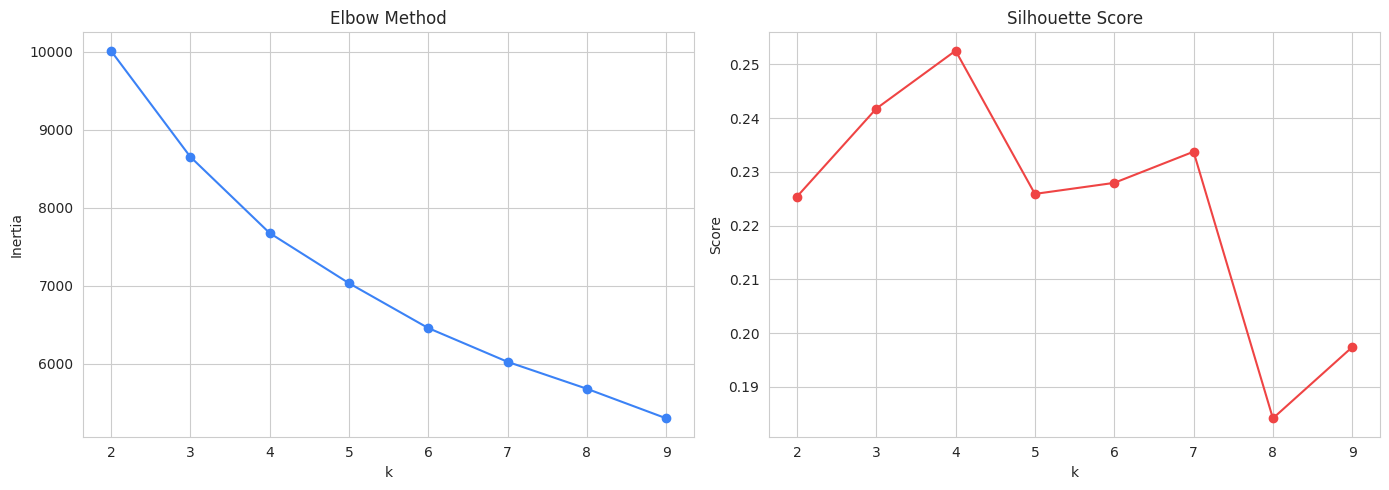

Best k by silhouette score: 4


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

cluster_features = ["market_value_eur_capped","caps","age_years","career_goals","tournament_goals",
                     "assists","minutes_per_match","start_rate","discipline_index","elo_rating"]
X_cluster = df[cluster_features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method
inertias, sils = [], []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, marker="o", color="#3B82F6")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(K_range), sils, marker="o", color="#EF4444")
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout()
plt.savefig("kmeans_elbow_silhouette.png", dpi=120)
plt.show()

best_k = list(K_range)[int(np.argmax(sils))]
print("Best k by silhouette score:", best_k)

PCA explained variance ratio: [0.28606327 0.18999968]   total: 0.4760629492032368


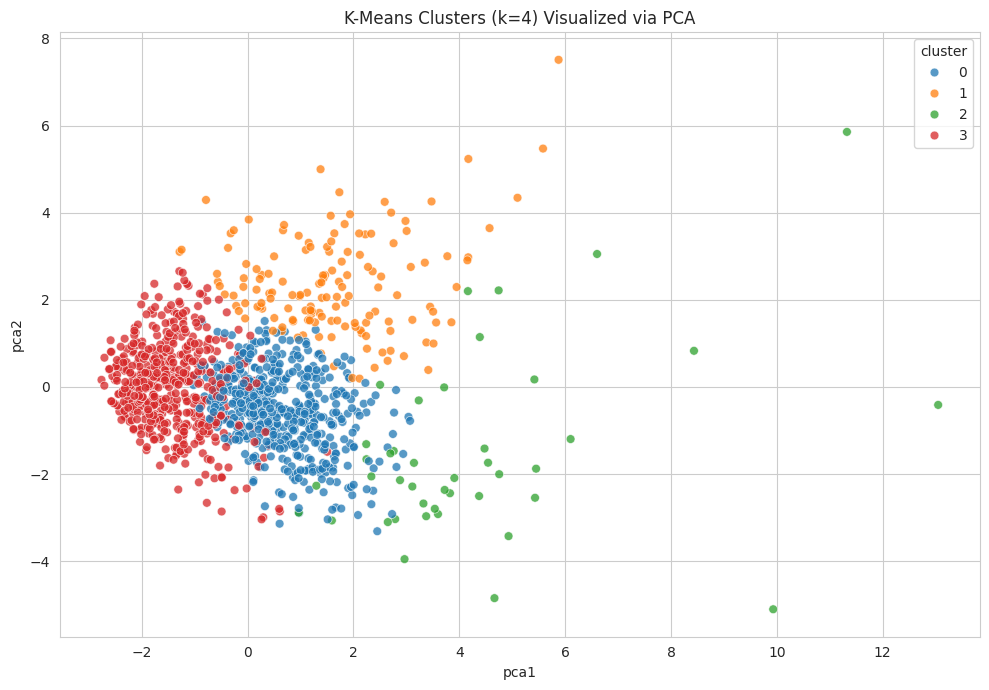

         market_value_eur_capped   caps  age_years  career_goals  tournament_goals  assists  minutes_per_match  start_rate  discipline_index  elo_rating
cluster                                                                                                                                                 
0                      8720088.4   42.5       28.7           3.4               0.1      0.1               76.3         0.9               0.4      1759.7
1                     57194289.4   31.7       25.6           4.9               0.8      0.8               67.1         0.7               0.4      2003.1
2                     18531788.5  116.9       33.0          48.2               1.7      0.7               68.2         0.8               0.5      1841.9
3                      9452186.7   22.0       27.4           2.1               0.1      0.0               14.4         0.1               0.0      1783.8


In [17]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)
df["pca1"], df["pca2"] = pcs[:,0], pcs[:,1]
print("PCA explained variance ratio:", pca.explained_variance_ratio_, "  total:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(10,7))
sns.scatterplot(data=df, x="pca1", y="pca2", hue="cluster", palette="tab10", alpha=0.75, s=40)
plt.title(f"K-Means Clusters (k={best_k}) Visualized via PCA")
plt.tight_layout()
plt.savefig("pca_clusters.png", dpi=120)
plt.show()

print(df.groupby("cluster")[cluster_features].mean().round(1))

## 8. Association Rule Mining (Apriori)

We bin key performance metrics into categorical "high/low" flags per player
and mine which trait combinations tend to co-occur (e.g. does "high minutes"
associate with "high market value"?).

In [18]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

def flag(col, label):
    return np.where(df[col] >= df[col].median(), f"High_{label}", f"Low_{label}")

basket_df = pd.DataFrame({
    "MarketValue": flag("market_value_eur", "MarketValue"),
    "Caps": flag("caps", "Caps"),
    "Minutes": flag("minutes_played", "Minutes"),
    "GoalInvolvement": flag("goal_involvement", "GoalInvolvement"),
    "Discipline": flag("discipline_index", "Discipline"),
    "EloRating": flag("elo_rating", "EloRating"),
    "Position": df["position"],
})
transactions = basket_df.astype(str).values.tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
te_df = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(te_df, min_support=0.10, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.3)
# Keep rules that are readable and meaningfully strong: short, confident, and above-chance
rules = rules[(rules["antecedents"].apply(len) <= 2) &
              (rules["consequents"].apply(len) == 1) &
              (rules["confidence"] >= 0.5)]
rules["antecedents"] = rules["antecedents"].apply(lambda s: ", ".join(sorted(s)))
rules["consequents"] = rules["consequents"].apply(lambda s: ", ".join(sorted(s)))
rules = rules.drop_duplicates(subset=["antecedents","consequents"])
rules = rules.sort_values("lift", ascending=False).reset_index(drop=True)
print(f"Total meaningful rules found: {len(rules)}")
rules[["antecedents","consequents","support","confidence","lift"]].head(15)

Total meaningful rules found: 51


,antecedents,consequents,support,confidence,lift
0,"High_EloRating, High_Minutes",High_MarketValue,0.209936,0.798780,1.597561
1,"Low_EloRating, Low_Minutes",Low_MarketValue,0.203526,0.779141,1.558282
2,"High_EloRating, MID",High_MarketValue,0.120994,0.774359,1.548718
3,"High_Caps, High_EloRating",High_MarketValue,0.198718,0.763077,1.526154
4,"Low_Caps, Low_EloRating",Low_MarketValue,0.193910,0.761006,1.522013
5,"High_Minutes, Low_MarketValue",Low_EloRating,0.162660,0.754647,1.509294
6,"High_MarketValue, MID",High_EloRating,0.120994,0.751244,1.502488
7,"High_Caps, Low_MarketValue",Low_EloRating,0.172276,0.736301,1.472603
8,"DEF, Low_EloRating",Low_MarketValue,0.127404,0.736111,1.472222
9,"High_MarketValue, High_Minutes",High_EloRating,0.209936,0.733894,1.467787


### Reading the rules
Rules with **lift > 1** mean the antecedent and consequent occur together
*more often than random chance* — e.g. a rule like
`{High_EloRating} -> {High_MarketValue}` with high confidence/lift tells us
players from strong (high Elo) national teams are disproportionately likely
to also be high-market-value players.

## 9. Supervised Learning — Setup

**Target:** `is_high_value` — is this player in the top quartile of market value?
**Split:** 80% train / 20% test, stratified, `random_state=42`.

**Two feature sets are compared throughout this section** — this directly answers
"how much of a player's predicted value comes from playing for a strong team,
vs. his own individual output?":

- **Full (with team context)** — includes `elo_rating` and `fifa_ranking_pre_tournament`
- **Individual Skill Only** — same features, minus those two team-level signals

We also address the **class imbalance** (~26% positive) head-on with three
complementary fixes, rather than just reporting weak recall:
1. `class_weight='balanced'` / `scale_pos_weight` / `is_unbalance` per algorithm
2. GridSearchCV hyperparameter tuning that includes the weighting option itself
   in the search space (not just tree depth / learning rate)
3. **Decision-threshold tuning** — the default 0.5 cutoff is rarely optimal
   under imbalance; we find the F1-optimal threshold via cross-validated
   probabilities on the *training* set only (no test leakage) and apply it.

In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Features deliberately EXCLUDE market_value_eur itself (and direct derivatives) to avoid leakage
TEAM_CONTEXT_COLS = ["elo_rating", "fifa_ranking_pre_tournament"]
INDIVIDUAL_COLS = ["caps","height_cm","career_goals","matches_played","matches_started","minutes_played",
                    "tournament_goals","assists","yellow_cards","red_cards","penalty_goals","own_goals",
                    "age_years","start_rate","minutes_per_match","goal_involvement","discipline_index",
                    "clean_sheets","saves","goals_conceded"]
cat_cols = ["position"]

def build_xy(feature_cols):
    X = df[feature_cols + cat_cols].copy()
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    y = df["is_high_value"]
    return X, y

X_full, y = build_xy(INDIVIDUAL_COLS + TEAM_CONTEXT_COLS)
X_indiv, _ = build_xy(INDIVIDUAL_COLS)

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
# Individual-only sets share the SAME row split (use .loc on the same index)
X_train_indiv, X_test_indiv = X_indiv.loc[X_train.index], X_indiv.loc[X_test.index]

print("Full feature set:", X_full.shape[1], "features |", "Individual-only:", X_indiv.shape[1], "features")
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)
scaler_indiv = StandardScaler()
X_train_indiv_scaled = scaler_indiv.fit_transform(X_train_indiv)
X_test_indiv_scaled = scaler_indiv.transform(X_test_indiv)

uses_scaled = {"Logistic Regression", "KNN", "SVM (RBF)"}
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"\nClass imbalance ratio (neg/pos) for scale_pos_weight: {scale_pos_weight:.2f}")

Full feature set: 25 features | Individual-only: 23 features
Train shape: (998, 25)  Test shape: (250, 25)
Train class balance:
 is_high_value
0    0.742
1    0.258
Name: proportion, dtype: float64
Test class balance:
 is_high_value
0    0.74
1    0.26
Name: proportion, dtype: float64



Class imbalance ratio (neg/pos) for scale_pos_weight: 2.88


## 10. Baseline — 8 Algorithms, Unweighted vs Class-Weighted (Full feature set)

This isolates exactly how much class-weighting alone buys us in recall, before
any other tuning.

In [20]:
def make_models(weighted: bool):
    return {
        "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE,
                                                    class_weight="balanced" if weighted else None),
        "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE,
                                                  class_weight="balanced" if weighted else None),
        "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE,
                                                   class_weight="balanced" if weighted else None),
        "Gradient Boosting (GBRT)": GradientBoostingClassifier(random_state=RANDOM_STATE),  # weighted via sample_weight
        "KNN": KNeighborsClassifier(),  # no native class weighting
        "SVM (RBF)": SVC(probability=True, random_state=RANDOM_STATE,
                          class_weight="balanced" if weighted else None),
        "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss",
                                   scale_pos_weight=scale_pos_weight if weighted else 1),
        "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1,
                                     class_weight="balanced" if weighted else None),
    }

def evaluate_model(name, model, use_scaled, weighted=False):
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled if use_scaled else X_test
    if name == "Gradient Boosting (GBRT)" and weighted:
        model.fit(Xtr, y_train, sample_weight=compute_sample_weight("balanced", y_train))
    else:
        model.fit(Xtr, y_train)
    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xte)
    test_proba = model.predict_proba(Xte)[:, 1]
    return {
        "Model": name, "Weighting": "Balanced" if weighted else "Unweighted",
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred),
        "Recall": recall_score(y_test, test_pred),
        "F1-Score": f1_score(y_test, test_pred),
        "ROC-AUC": roc_auc_score(y_test, test_proba),
        "_model": model, "_proba": test_proba, "_pred": test_pred
    }

baseline_results, weighted_results = [], []
for n, m in make_models(weighted=False).items():
    baseline_results.append(evaluate_model(n, m, n in uses_scaled, weighted=False))
for n, m in make_models(weighted=True).items():
    weighted_results.append(evaluate_model(n, m, n in uses_scaled, weighted=True))

baseline_table = pd.DataFrame(baseline_results).drop(columns=["_model","_proba","_pred"])
weighted_table = pd.DataFrame(weighted_results).drop(columns=["_model","_proba","_pred"])
imbalance_comparison = pd.concat([baseline_table, weighted_table]).sort_values(
    ["Model", "Weighting"]).reset_index(drop=True)

print("=== UNWEIGHTED vs CLASS-WEIGHTED — RECALL COMPARISON ===")
imbalance_comparison[["Model","Weighting","Precision","Recall","F1-Score","ROC-AUC"]].round(4)

=== UNWEIGHTED vs CLASS-WEIGHTED — RECALL COMPARISON ===


,Model,Weighting,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,Balanced,0.6667,0.6154,0.6400,0.7536
1,Decision Tree,Unweighted,0.6212,0.6308,0.6260,0.7478
2,Gradient Boosting (GBRT),Balanced,0.8182,0.8308,0.8244,0.9457
3,Gradient Boosting (GBRT),Unweighted,0.8800,0.6769,0.7652,0.9435
4,KNN,Balanced,0.6818,0.4615,0.5505,0.7946
5,KNN,Unweighted,0.6818,0.4615,0.5505,0.7946
6,LightGBM,Balanced,0.7761,0.8000,0.7879,0.9309
7,LightGBM,Unweighted,0.8519,0.7077,0.7731,0.9302
8,Logistic Regression,Balanced,0.6098,0.7692,0.6803,0.9077
9,Logistic Regression,Unweighted,0.7451,0.5846,0.6552,0.9099


In [21]:
recall_lift = (weighted_table.set_index("Model")["Recall"] - baseline_table.set_index("Model")["Recall"]).sort_values(ascending=False)
print("Recall change from class-weighting alone (Balanced - Unweighted):")
print(recall_lift.round(3))

Recall change from class-weighting alone (Balanced - Unweighted):
Model
SVM (RBF)                   0.354
Logistic Regression         0.185
Gradient Boosting (GBRT)    0.154
LightGBM                    0.092
XGBoost                     0.031
KNN                         0.000
Decision Tree              -0.015
Random Forest              -0.015
Name: Recall, dtype: float64


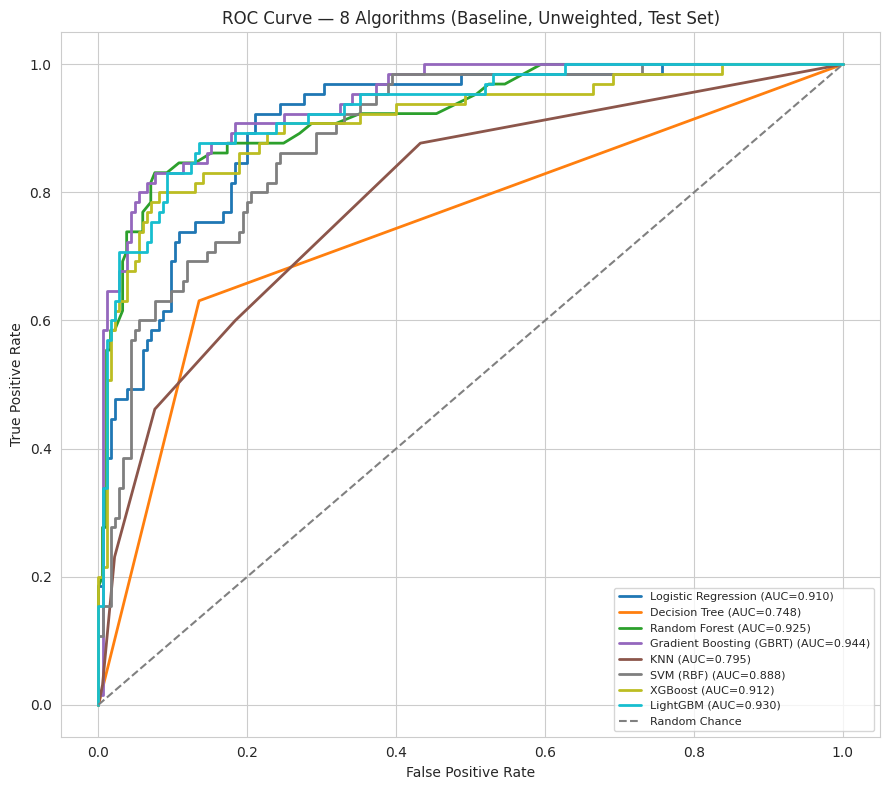

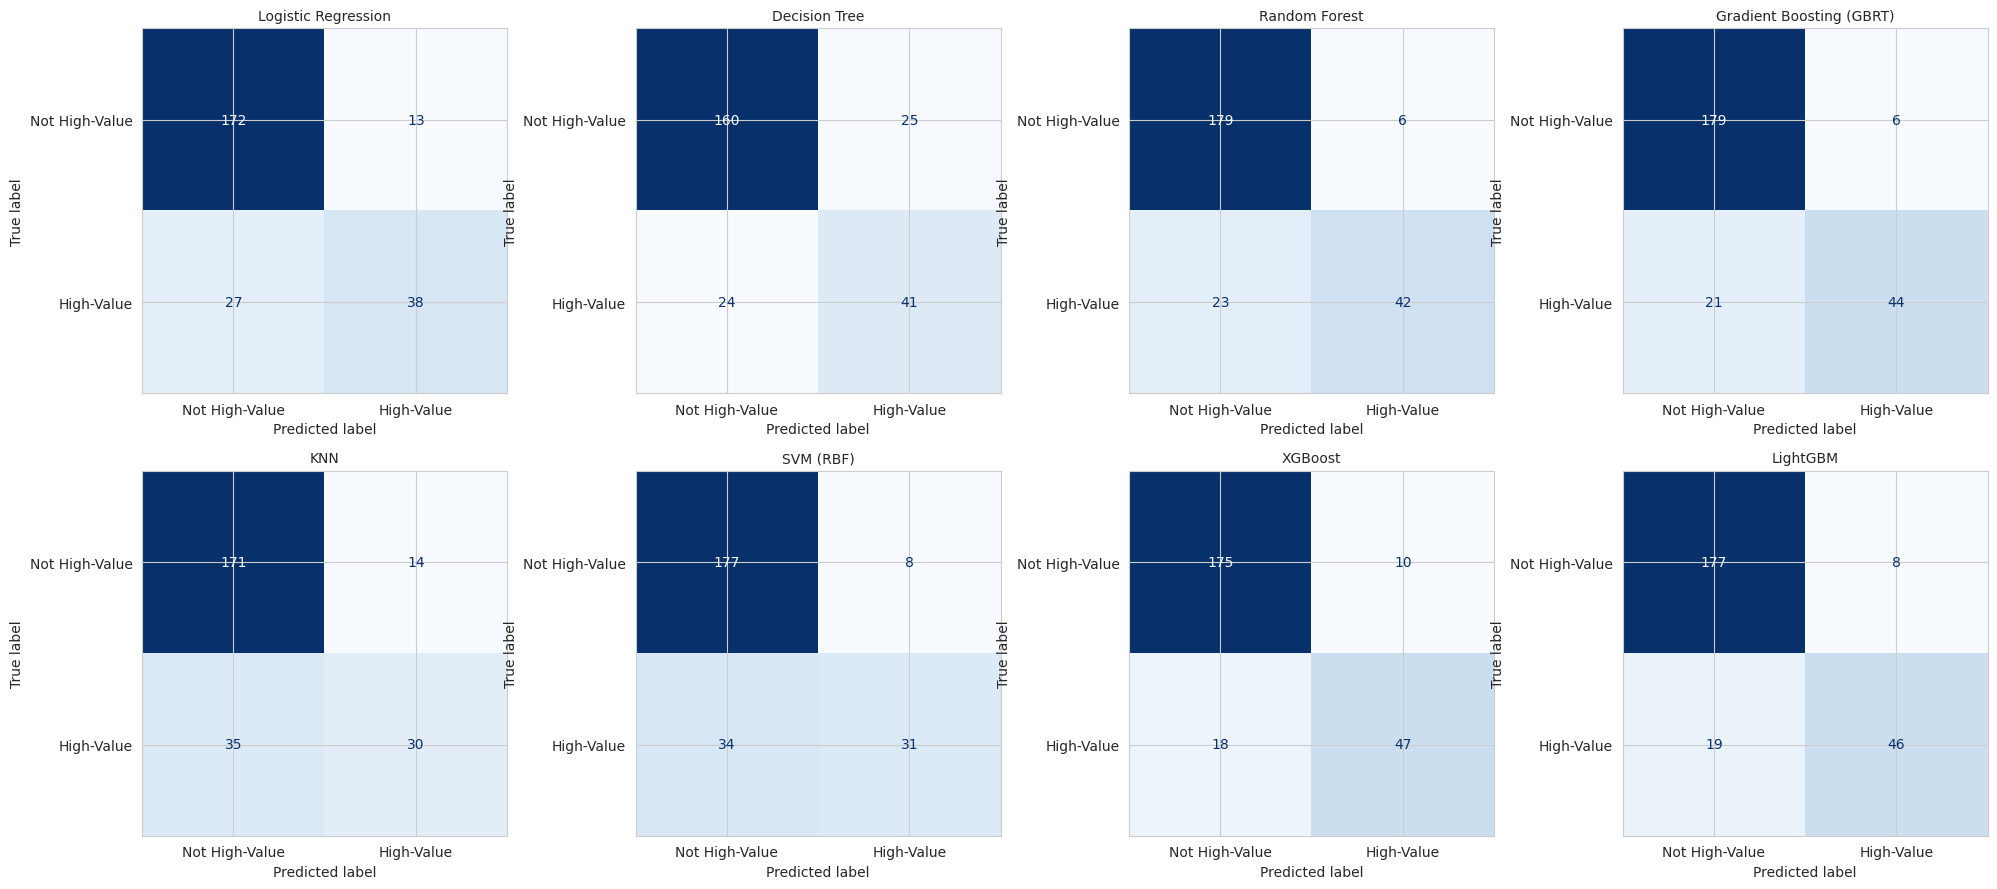

In [22]:
roc_rows, cm_rows = [], []
for res in baseline_results:
    fpr, tpr, _ = roc_curve(y_test, res["_proba"])
    for f, t in zip(fpr, tpr):
        roc_rows.append({"dataset": "Baseline", "Model": res["Model"], "fpr": f, "tpr": t, "AUC": res["ROC-AUC"]})
    tn, fp, fn, tp = confusion_matrix(y_test, res["_pred"]).ravel()
    cm_rows.append({"dataset": "Baseline", "Model": res["Model"], "TN": tn, "FP": fp, "FN": fn, "TP": tp})
pd.DataFrame(roc_rows).to_csv("roc_curve_data_baseline.csv", index=False)
pd.DataFrame(cm_rows).to_csv("confusion_matrix_data_baseline.csv", index=False)

colors = plt.cm.tab10(np.linspace(0, 1, len(baseline_results)))
plt.figure(figsize=(9, 8))
for res, c in zip(baseline_results, colors):
    fpr, tpr, _ = roc_curve(y_test, res["_proba"])
    plt.plot(fpr, tpr, color=c, lw=2, label=f"{res['Model']} (AUC={res['ROC-AUC']:.3f})")
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Random Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — 8 Algorithms (Baseline, Unweighted, Test Set)")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("roc_curve_baseline_all_models.png", dpi=150)
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, res in zip(axes.flatten(), baseline_results):
    cm = confusion_matrix(y_test, res["_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Not High-Value","High-Value"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(res["Model"], fontsize=10)
plt.tight_layout()
plt.savefig("confusion_matrices_baseline.png", dpi=120)
plt.show()

## 11. GridSearchCV Tuning (5-Fold CV) — Weighting *and* Regularization in the Search Space

Scoring is **F1** (not accuracy/ROC-AUC alone) because the goal is a better
precision/recall balance under imbalance. ROC-AUC is still tracked from the
same CV folds for comparability with the notebook's earlier tables.

**Overfitting control.** The first pass at tuning let Random Forest, XGBoost and
KNN reach ~100% *resubstitution* train accuracy (predicting on the exact rows
they were fit on) — a red flag for high-capacity models on ~1,000 rows. Two
things are done about it here:

1. The grids now include explicit **regularization knobs** — `min_samples_leaf`,
   `max_features` (Random Forest); `subsample`, `colsample_bytree`, `reg_lambda`,
   `min_child_weight` (XGBoost); `min_child_samples` (LightGBM) — instead of
   letting trees grow unconstrained.
2. "Train Accuracy" is no longer computed by predicting on the same rows the
   model was fit on (resubstitution accuracy), which is trivially inflated —
   for **KNN with `weights='distance'` it's a pure artifact**: every training
   point's nearest neighbor during self-prediction is itself, at distance 0,
   so it always votes for its own label. Instead we report **out-of-fold (OOF)
   train accuracy** via `cross_val_predict` — each training row is only ever
   predicted by a model that did *not* see it during that fold's fit. This is
   a fair proxy for generalization, computed without ever touching the test set.

In [23]:
param_grids = {
    "Logistic Regression": (LogisticRegression(max_iter=3000, random_state=RANDOM_STATE), {
        "C": [0.01, 0.1, 1, 10], "class_weight": [None, "balanced"]
    }),
    "Decision Tree": (DecisionTreeClassifier(random_state=RANDOM_STATE), {
        "max_depth": [3, 5, 8, 12], "min_samples_split": [2, 10], "min_samples_leaf": [1, 10],
        "criterion": ["gini","entropy"], "class_weight": [None, "balanced"]
    }),
    "Random Forest": (RandomForestClassifier(random_state=RANDOM_STATE, max_features="sqrt"), {
        "n_estimators": [200, 300], "max_depth": [6, 10], "min_samples_leaf": [1, 4],
        "class_weight": [None, "balanced"]
    }),
    "Gradient Boosting (GBRT)": (GradientBoostingClassifier(random_state=RANDOM_STATE, subsample=0.9), {
        "n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [2, 3],
        "min_samples_leaf": [1, 10]
    }),
    "KNN": (KNeighborsClassifier(), {
        "n_neighbors": [5, 9, 15, 25], "weights": ["uniform","distance"]
    }),
    "SVM (RBF)": (SVC(probability=True, random_state=RANDOM_STATE), {
        "C": [0.1, 1, 10], "gamma": ["scale", "auto"], "class_weight": [None, "balanced"]
    }),
    "XGBoost": (XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss",
                                n_estimators=200, subsample=0.8, colsample_bytree=0.8), {
        "max_depth": [3, 5], "learning_rate": [0.05, 0.1], "reg_lambda": [1, 5],
        "min_child_weight": [1, 5], "scale_pos_weight": [1, scale_pos_weight]
    }),
    "LightGBM": (LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1, n_estimators=200), {
        "max_depth": [3, 5, -1], "learning_rate": [0.05, 0.1], "min_child_samples": [10, 30],
        "class_weight": [None, "balanced"]
    }),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

tuned_results, best_estimators = [], {}
gbrt_sample_weight = compute_sample_weight("balanced", y_train)
for name, (estimator, grid) in param_grids.items():
    use_scaled = name in uses_scaled
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled if use_scaled else X_test
    gs = GridSearchCV(estimator, grid, scoring={"f1": "f1", "roc_auc": "roc_auc"},
                       refit="f1", cv=cv, n_jobs=1)
    if name == "Gradient Boosting (GBRT)":
        # sklearn's GBRT has no class_weight param -> apply balanced sample_weight directly
        gs.fit(Xtr, y_train, sample_weight=gbrt_sample_weight)
    else:
        gs.fit(Xtr, y_train)
    best_estimators[name] = gs.best_estimator_

    # Resubstitution train accuracy (the OLD, inflated way — kept for the before/after comparison)
    resub_train_pred = gs.predict(Xtr)
    resub_train_acc = accuracy_score(y_train, resub_train_pred)

    # Honest out-of-fold train accuracy (each row predicted by a model that never saw it)
    from sklearn.base import clone
    oof_estimator = clone(gs.best_estimator_)
    if name == "Gradient Boosting (GBRT)":
        oof_proba = cross_val_predict(oof_estimator, Xtr, y_train, cv=cv, method="predict_proba",
                                       n_jobs=1, params={"sample_weight": gbrt_sample_weight})[:, 1]
    else:
        oof_proba = cross_val_predict(oof_estimator, Xtr, y_train, cv=cv, method="predict_proba", n_jobs=1)[:, 1]
    oof_train_pred = (oof_proba >= 0.5).astype(int)
    oof_train_acc = accuracy_score(y_train, oof_train_pred)

    test_pred = gs.predict(Xte)
    test_proba = gs.predict_proba(Xte)[:, 1]
    cv_f1 = gs.cv_results_["mean_test_f1"][gs.best_index_]
    cv_auc = gs.cv_results_["mean_test_roc_auc"][gs.best_index_]
    test_acc = accuracy_score(y_test, test_pred)
    tuned_results.append({
        "Model": name, "Best Params": str(gs.best_params_),
        "CV F1 (5-fold)": cv_f1, "CV ROC-AUC (5-fold)": cv_auc,
        "Resubstitution Train Acc": resub_train_acc,
        "OOF Train Acc (honest)": oof_train_acc,
        "Test Accuracy": test_acc,
        "Resubstitution Gap": resub_train_acc - test_acc,
        "OOF Gap (honest)": oof_train_acc - test_acc,
        "Precision": precision_score(y_test, test_pred),
        "Recall": recall_score(y_test, test_pred),
        "F1-Score": f1_score(y_test, test_pred),
        "ROC-AUC": roc_auc_score(y_test, test_proba),
        "_proba": test_proba, "_pred": test_pred
    })
    print(f"Done: {name}  best_params={gs.best_params_}  "
          f"resub_gap={resub_train_acc - test_acc:.3f}  oof_gap={oof_train_acc - test_acc:.3f}")

tuned_table = pd.DataFrame(tuned_results).drop(columns=["_proba","_pred"])
tuned_table = tuned_table.sort_values("F1-Score", ascending=False).reset_index(drop=True)
print("\n=== TUNED MODEL COMPARISON (GridSearchCV, 5-fold CV, scored on F1) ===")
tuned_table.round(4)

Done: Logistic Regression  best_params={'C': 0.1, 'class_weight': None}  resub_gap=0.022  oof_gap=0.017


Done: Decision Tree  best_params={'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 12, 'min_samples_leaf': 10, 'min_samples_split': 2}  resub_gap=0.078  oof_gap=0.006


Done: Random Forest  best_params={'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 300}  resub_gap=0.110  oof_gap=-0.012


Done: Gradient Boosting (GBRT)  best_params={'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 10, 'n_estimators': 200}  resub_gap=0.027  oof_gap=-0.036


Done: KNN  best_params={'n_neighbors': 9, 'weights': 'distance'}  resub_gap=0.192  oof_gap=0.020


Done: SVM (RBF)  best_params={'C': 1, 'class_weight': 'balanced', 'gamma': 'scale'}  resub_gap=0.011  oof_gap=0.004


Done: XGBoost  best_params={'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'reg_lambda': 5, 'scale_pos_weight': 1}  resub_gap=0.045  oof_gap=-0.008


Done: LightGBM  best_params={'class_weight': None, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 30}  resub_gap=0.112  oof_gap=-0.010

=== TUNED MODEL COMPARISON (GridSearchCV, 5-fold CV, scored on F1) ===


,Model,Best Params,CV F1 (5-fold),CV ROC-AUC (5-fold),Resubstitution Train Acc,OOF Train Acc (honest),Test Accuracy,Resubstitution Gap,OOF Gap (honest),Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting (GBRT),"{'learning_rate': 0.1, 'max_depth': 2, 'min_sa...",0.8367,0.9240,0.9269,0.8637,0.900,0.0269,-0.0363,0.7941,0.8308,0.8120,0.9435
1,LightGBM,"{'class_weight': None, 'learning_rate': 0.1, '...",0.7488,0.9210,1.0000,0.8778,0.888,0.1120,-0.0102,0.8246,0.7231,0.7705,0.9293
2,XGBoost,"{'learning_rate': 0.05, 'max_depth': 3, 'min_c...",0.7537,0.9264,0.9329,0.8798,0.888,0.0449,-0.0082,0.8491,0.6923,0.7627,0.9359
3,Random Forest,"{'class_weight': 'balanced', 'max_depth': 10, ...",0.7286,0.9143,0.9940,0.8717,0.884,0.1100,-0.0123,0.8600,0.6615,0.7478,0.9328
4,SVM (RBF),"{'C': 1, 'class_weight': 'balanced', 'gamma': ...",0.6540,0.8802,0.8427,0.8357,0.832,0.0107,0.0037,0.6353,0.8308,0.7200,0.9141
5,Decision Tree,"{'class_weight': 'balanced', 'criterion': 'ent...",0.6975,0.8855,0.8938,0.8216,0.816,0.0778,0.0056,0.6267,0.7231,0.6714,0.8763
6,Logistic Regression,"{'C': 0.1, 'class_weight': None}",0.6899,0.8980,0.8617,0.8567,0.840,0.0217,0.0167,0.7660,0.5538,0.6429,0.9117
7,KNN,"{'n_neighbors': 9, 'weights': 'distance'}",0.5787,0.8461,1.0000,0.8277,0.808,0.1920,0.0197,0.7429,0.4000,0.5200,0.8227


### Did regularization actually fix the overfitting?

Compare `Resubstitution Gap` (the old, inflated diagnostic) to `OOF Gap` (the
honest one) below. A large positive gap means the model memorizes training
rows it shouldn't be able to generalize from; a small gap means its held-out
behavior is close to its held-in behavior.

                   Model  Resubstitution Train Acc  OOF Train Acc (honest)  Test Accuracy  Resubstitution Gap  OOF Gap (honest)
                     KNN                    1.0000                  0.8277          0.808              0.1920            0.0197
     Logistic Regression                    0.8617                  0.8567          0.840              0.0217            0.0167
           Decision Tree                    0.8938                  0.8216          0.816              0.0778            0.0056
               SVM (RBF)                    0.8427                  0.8357          0.832              0.0107            0.0037
                 XGBoost                    0.9329                  0.8798          0.888              0.0449           -0.0082
                LightGBM                    1.0000                  0.8778          0.888              0.1120           -0.0102
           Random Forest                    0.9940                  0.8717          0.884              0

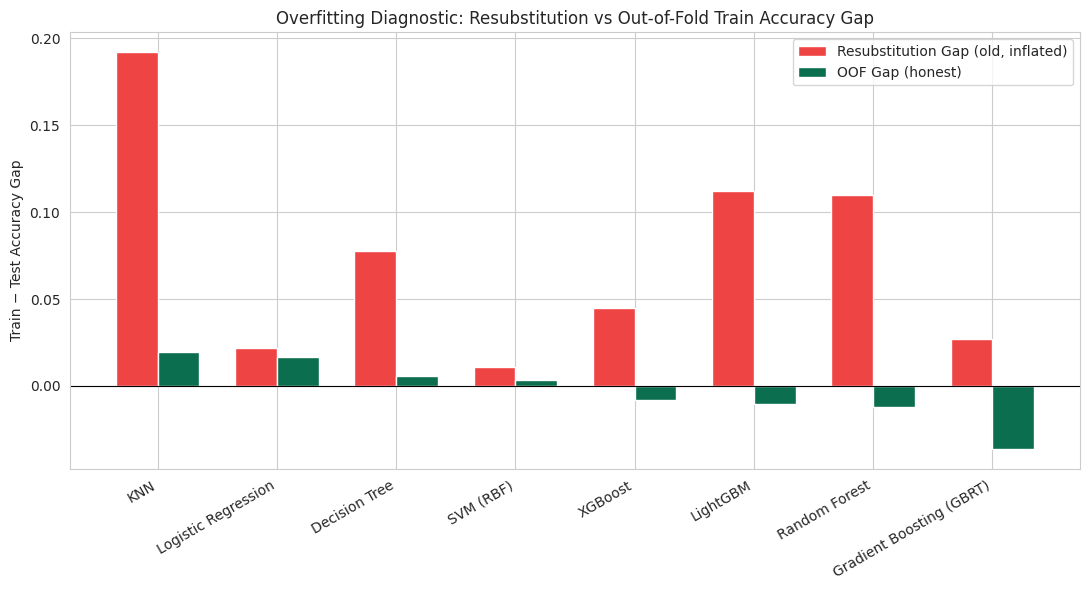

In [24]:
overfit_diag = tuned_table[["Model","Resubstitution Train Acc","OOF Train Acc (honest)",
                              "Test Accuracy","Resubstitution Gap","OOF Gap (honest)"]].round(4)
overfit_diag = overfit_diag.sort_values("OOF Gap (honest)", ascending=False)
print(overfit_diag.to_string(index=False))
overfit_diag.to_csv("overfitting_diagnostic.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(overfit_diag))
width = 0.35
ax.bar(x - width/2, overfit_diag["Resubstitution Gap"], width, label="Resubstitution Gap (old, inflated)", color="#EF4444")
ax.bar(x + width/2, overfit_diag["OOF Gap (honest)"], width, label="OOF Gap (honest)", color="#0B6E4F")
ax.set_xticks(x); ax.set_xticklabels(overfit_diag["Model"], rotation=30, ha="right")
ax.set_ylabel("Train − Test Accuracy Gap")
ax.set_title("Overfitting Diagnostic: Resubstitution vs Out-of-Fold Train Accuracy Gap")
ax.axhline(0, color="black", lw=0.8)
ax.legend()
plt.tight_layout()
plt.savefig("overfitting_diagnostic.png", dpi=120)
plt.show()

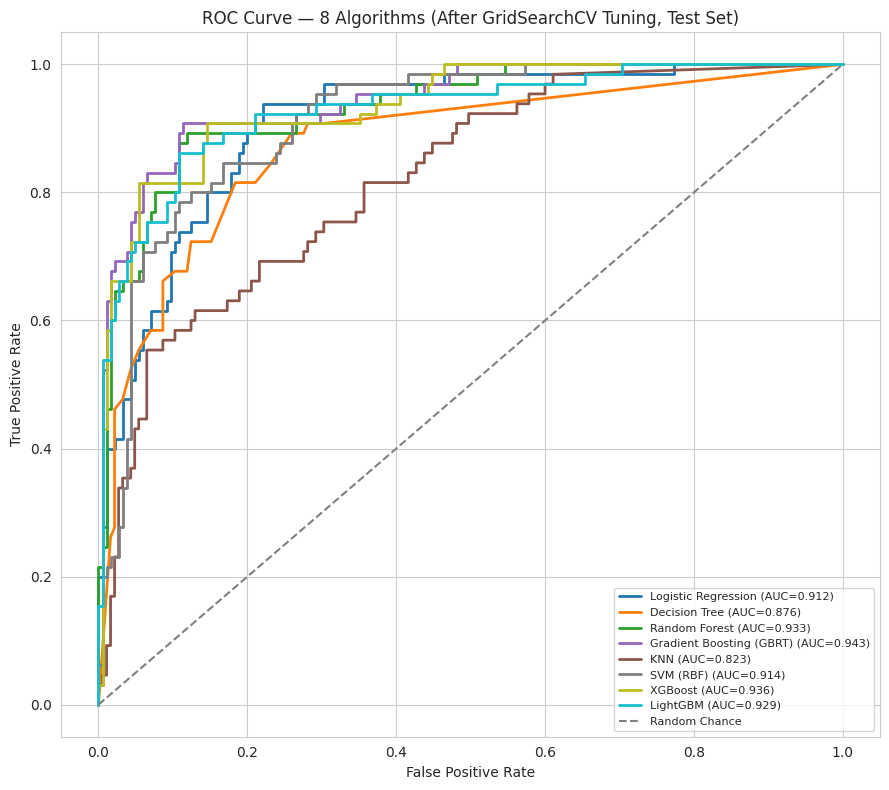

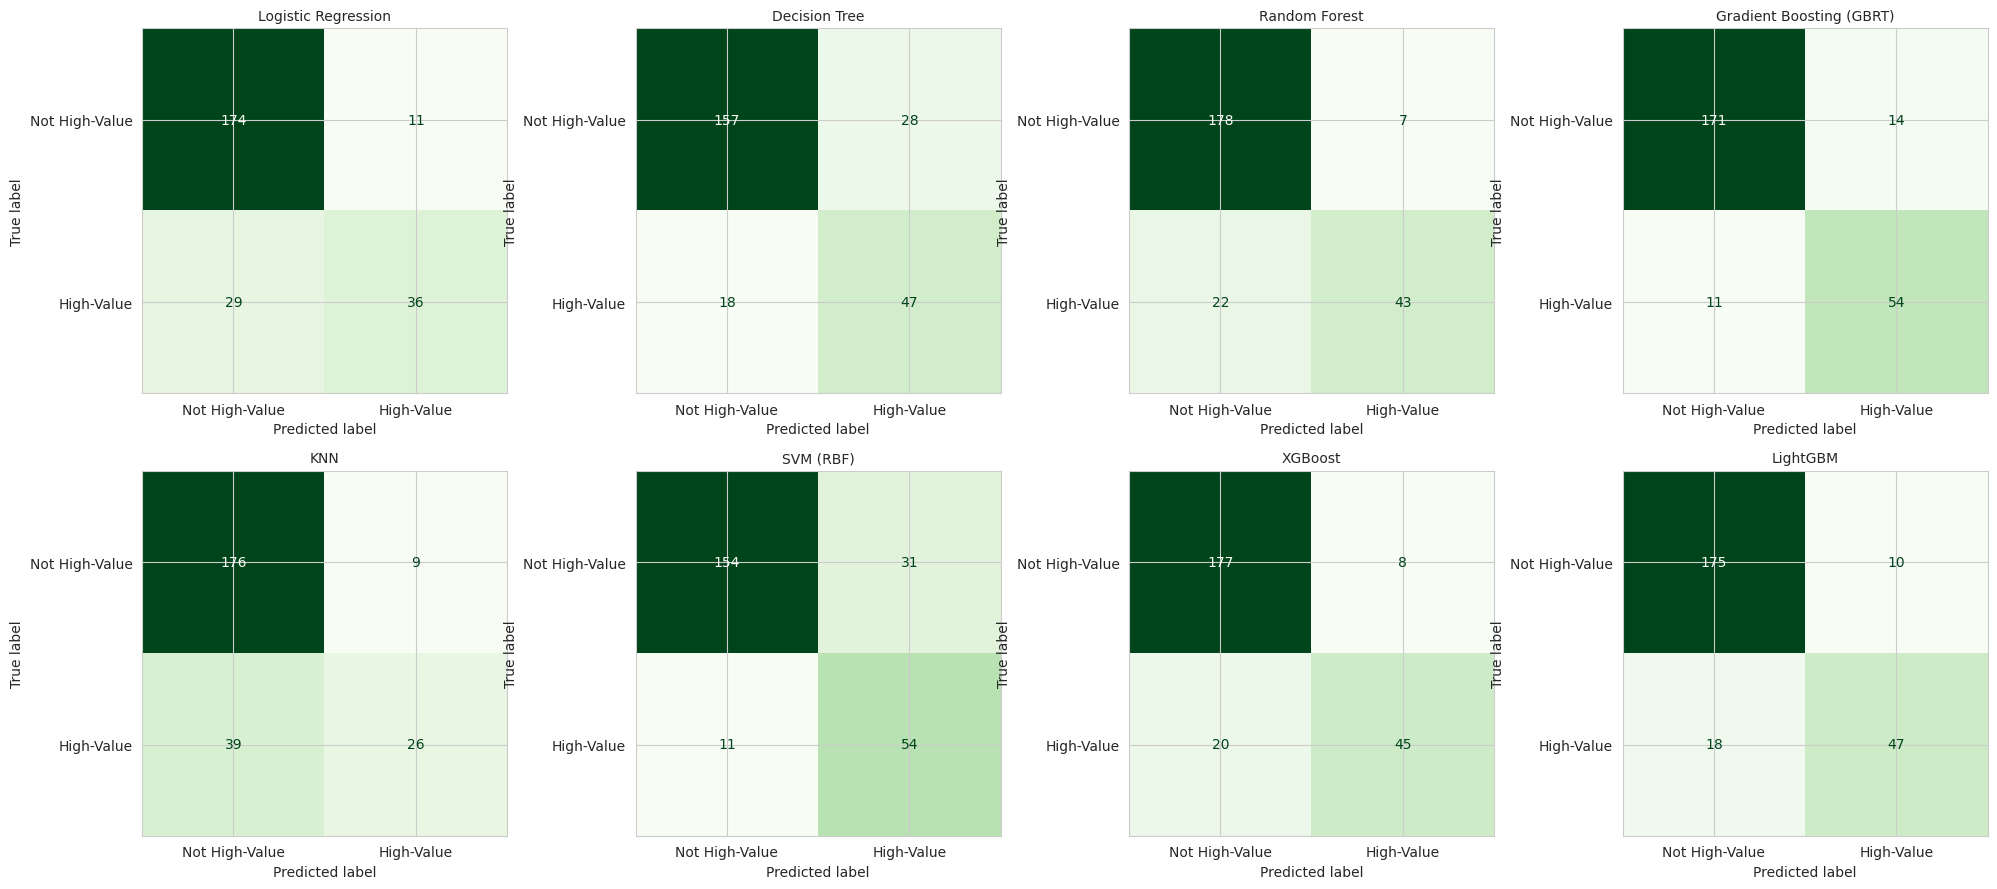

In [25]:
roc_rows_t, cm_rows_t = [], []
for res in tuned_results:
    fpr, tpr, _ = roc_curve(y_test, res["_proba"])
    for f, t in zip(fpr, tpr):
        roc_rows_t.append({"dataset": "Tuned", "Model": res["Model"], "fpr": f, "tpr": t, "AUC": res["ROC-AUC"]})
    tn, fp, fn, tp = confusion_matrix(y_test, res["_pred"]).ravel()
    cm_rows_t.append({"dataset": "Tuned", "Model": res["Model"], "TN": tn, "FP": fp, "FN": fn, "TP": tp})
pd.DataFrame(roc_rows_t).to_csv("roc_curve_data_tuned.csv", index=False)
pd.DataFrame(cm_rows_t).to_csv("confusion_matrix_data_tuned.csv", index=False)

plt.figure(figsize=(9, 8))
for res, c in zip(tuned_results, colors):
    fpr, tpr, _ = roc_curve(y_test, res["_proba"])
    plt.plot(fpr, tpr, color=c, lw=2, label=f"{res['Model']} (AUC={res['ROC-AUC']:.3f})")
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Random Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — 8 Algorithms (After GridSearchCV Tuning, Test Set)")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("roc_curve_tuned_all_models.png", dpi=150)
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, res in zip(axes.flatten(), tuned_results):
    cm = confusion_matrix(y_test, res["_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Not High-Value","High-Value"]).plot(ax=ax, colorbar=False, cmap="Greens")
    ax.set_title(res["Model"], fontsize=10)
plt.tight_layout()
plt.savefig("confusion_matrices_tuned.png", dpi=120)
plt.show()

## 12. Decision-Threshold Tuning

The default 0.5 cutoff is arbitrary under class imbalance. For the best
tuned model, we find the F1-optimal threshold using **cross-validated
probabilities on the training set only** (`cross_val_predict`, 5-fold) —
never touching the test set — then apply that single threshold once to test.

In [26]:
best_model_name = tuned_table.iloc[0]["Model"]
best_model = best_estimators[best_model_name]
use_scaled_best = best_model_name in uses_scaled
Xtr_best = X_train_scaled if use_scaled_best else X_train
Xte_best = X_test_scaled if use_scaled_best else X_test

cv_proba = cross_val_predict(best_model, Xtr_best, y_train, cv=cv, method="predict_proba", n_jobs=1)[:, 1]
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_train, cv_proba)
f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-12)
best_threshold = thresh_arr[np.argmax(f1_arr)]
print(f"Best model: {best_model_name}")
print(f"F1-optimal threshold (found via 5-fold CV on TRAIN only): {best_threshold:.3f}  (default is 0.50)")

test_proba_best = best_model.predict_proba(Xte_best)[:, 1]
pred_default = (test_proba_best >= 0.5).astype(int)
pred_tuned_thresh = (test_proba_best >= best_threshold).astype(int)

threshold_comparison = pd.DataFrame([
    {"Threshold": "Default (0.50)", "Precision": precision_score(y_test, pred_default),
     "Recall": recall_score(y_test, pred_default), "F1-Score": f1_score(y_test, pred_default),
     "Accuracy": accuracy_score(y_test, pred_default)},
    {"Threshold": f"F1-optimal ({best_threshold:.2f})", "Precision": precision_score(y_test, pred_tuned_thresh),
     "Recall": recall_score(y_test, pred_tuned_thresh), "F1-Score": f1_score(y_test, pred_tuned_thresh),
     "Accuracy": accuracy_score(y_test, pred_tuned_thresh)},
])
print("\n=== EFFECT OF THRESHOLD TUNING ON THE TEST SET ===")
threshold_comparison.round(4)

Best model: Gradient Boosting (GBRT)
F1-optimal threshold (found via 5-fold CV on TRAIN only): 0.455  (default is 0.50)

=== EFFECT OF THRESHOLD TUNING ON THE TEST SET ===


,Threshold,Precision,Recall,F1-Score,Accuracy
0,Default (0.50),0.7941,0.8308,0.8120,0.900
1,F1-optimal (0.46),0.7500,0.8308,0.7883,0.884


In [27]:
threshold_comparison.to_csv("threshold_tuning_comparison.csv", index=False)
recall_lift.reset_index().rename(columns={0: "Recall_Lift", "index":"Model"}).to_csv("class_weighting_recall_lift.csv", index=False)
imbalance_comparison.to_csv("model_results_imbalance_comparison.csv", index=False)

## 13. Team Context vs Individual Skill — How Much of the Signal Is "Playing for a Good Team"?

We retrain the same winning algorithm (same tuned hyperparameters where they
don't reference the feature count) on the **Individual Skill Only** feature
set and compare directly to the **Full** feature set result above.

In [28]:
def clone_best_for_indiv():
    from sklearn.base import clone
    return clone(best_model)

model_indiv = clone_best_for_indiv()
Xtr_i = X_train_indiv_scaled if use_scaled_best else X_train_indiv
Xte_i = X_test_indiv_scaled if use_scaled_best else X_test_indiv
model_indiv.fit(Xtr_i, y_train)
proba_indiv = model_indiv.predict_proba(Xte_i)[:, 1]
pred_indiv = model_indiv.predict(Xte_i)

team_vs_individual = pd.DataFrame([
    {"Feature Set": "Full (with team context: Elo + FIFA ranking)", "Test Accuracy": accuracy_score(y_test, pred_tuned_thresh if False else best_model.predict(Xte_best)),
     "Precision": precision_score(y_test, best_model.predict(Xte_best)), "Recall": recall_score(y_test, best_model.predict(Xte_best)),
     "F1-Score": f1_score(y_test, best_model.predict(Xte_best)), "ROC-AUC": roc_auc_score(y_test, test_proba_best)},
    {"Feature Set": "Individual Skill Only (no team context)", "Test Accuracy": accuracy_score(y_test, pred_indiv),
     "Precision": precision_score(y_test, pred_indiv), "Recall": recall_score(y_test, pred_indiv),
     "F1-Score": f1_score(y_test, pred_indiv), "ROC-AUC": roc_auc_score(y_test, proba_indiv)},
])
print(f"=== {best_model_name}: FULL vs INDIVIDUAL-ONLY FEATURE SET ===")
team_vs_individual.round(4)

=== Gradient Boosting (GBRT): FULL vs INDIVIDUAL-ONLY FEATURE SET ===


,Feature Set,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Full (with team context: Elo + FIFA ranking),0.900,0.7941,0.8308,0.812,0.9435
1,Individual Skill Only (no team context),0.792,0.6857,0.3692,0.480,0.7640


In [29]:
auc_drop = team_vs_individual.iloc[0]["ROC-AUC"] - team_vs_individual.iloc[1]["ROC-AUC"]
print(f"ROC-AUC drop when team context is removed: {auc_drop:.4f}")
print(f"({team_vs_individual.iloc[1]['ROC-AUC']/team_vs_individual.iloc[0]['ROC-AUC']*100:.1f}% of the Full model's discriminative power remains using individual stats alone)")
team_vs_individual.to_csv("team_vs_individual_comparison.csv", index=False)

ROC-AUC drop when team context is removed: 0.1795
(81.0% of the Full model's discriminative power remains using individual stats alone)


## 14. Feature Importance — Full Model vs Individual-Only Model

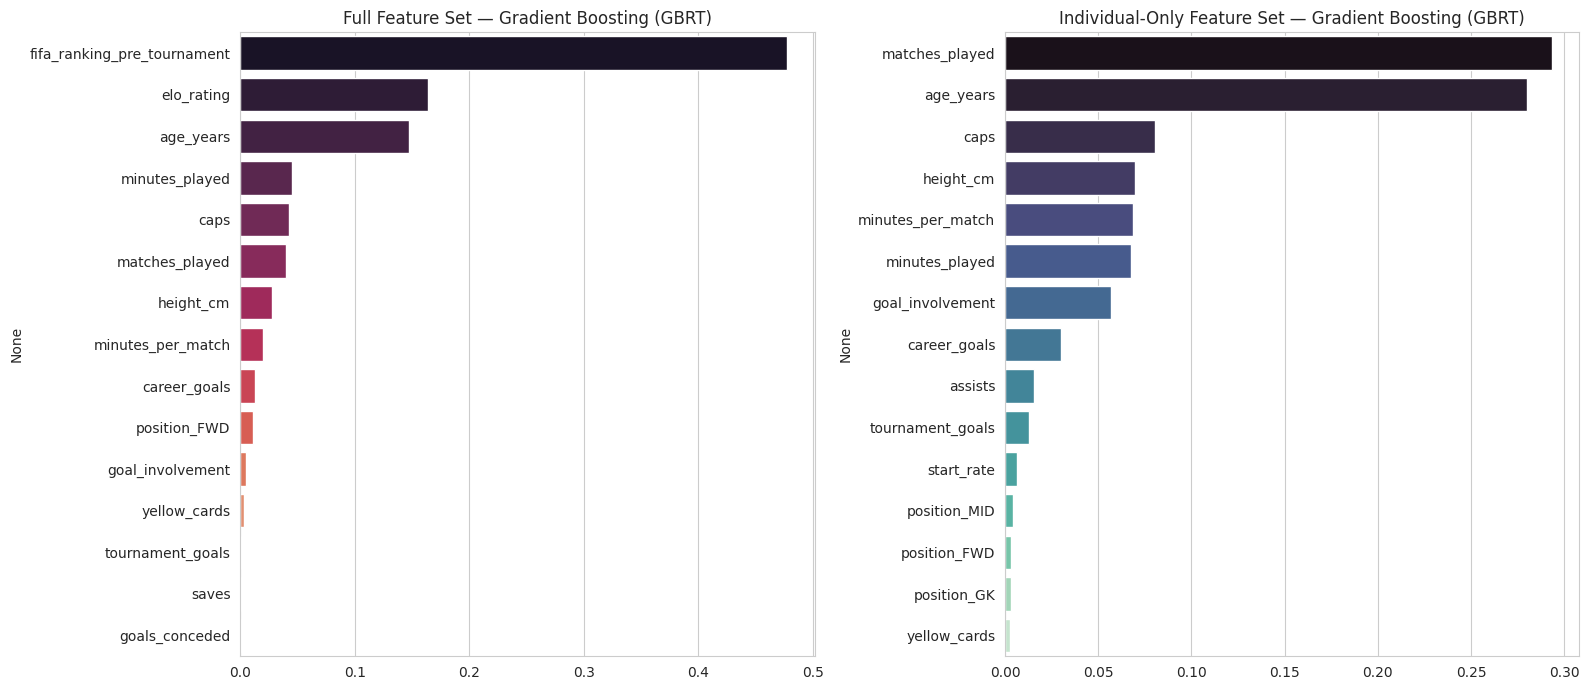

In [30]:
def get_importances(model, columns, top_n=15):
    if hasattr(model, "feature_importances_"):
        return pd.Series(model.feature_importances_, index=columns).sort_values(ascending=False).head(top_n)
    if hasattr(model, "coef_"):
        return pd.Series(np.abs(model.coef_[0]), index=columns).sort_values(ascending=False).head(top_n)
    return pd.Series(dtype=float)

imp_full = get_importances(best_model, X_train.columns)
imp_indiv = get_importances(model_indiv, X_train_indiv.columns)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
if len(imp_full):
    sns.barplot(x=imp_full.values, y=imp_full.index, ax=axes[0], palette="rocket")
    axes[0].set_title(f"Full Feature Set — {best_model_name}")
if len(imp_indiv):
    sns.barplot(x=imp_indiv.values, y=imp_indiv.index, ax=axes[1], palette="mako")
    axes[1].set_title(f"Individual-Only Feature Set — {best_model_name}")
plt.tight_layout()
plt.savefig("feature_importance_best_model.png", dpi=120)
plt.show()

imp_full.reset_index().rename(columns={"index": "feature", 0: "importance"}).to_csv("feature_importance.csv", index=False)
imp_indiv.reset_index().rename(columns={"index": "feature", 0: "importance"}).to_csv("feature_importance_individual_only.csv", index=False)

## 15. Save Artifacts for the Streamlit Dashboard

In [31]:
import joblib
baseline_table.to_csv("model_results_baseline.csv", index=False)
tuned_table.drop(columns=["Best Params"]).to_csv("model_results_tuned.csv", index=False)
tuned_table.to_csv("model_results_tuned_with_params.csv", index=False)
rules[["antecedents","consequents","support","confidence","lift"]].to_csv("association_rules.csv", index=False)
print(f"Saved {len(rules)} association rules.")
df.to_csv("fifa_wc2026_cleaned_enriched.csv", index=False)  # includes cluster/pca columns
joblib.dump(best_model, f"best_model_{best_model_name.replace(' ','_').replace('(','').replace(')','')}.joblib")

print("All artifacts saved. Ready for the Streamlit dashboard.")

Saved 51 association rules.
All artifacts saved. Ready for the Streamlit dashboard.


## 16. Key Insights Summary

1. **Data integrity**: All 1,248 player records were preserved; only 3
   genuinely empty columns were dropped. Missingness in goalkeeper stats was
   structural, not an error.
2. **Clustering** reveals distinct player archetypes driven mainly by market
   value, minutes played, and goal involvement rather than raw discipline stats.
3. **Association rules** show high Elo-rated national teams and high market
   value co-occur with high lift — squad strength correlates with individual
   player valuation.
4. **Imbalance fix worked**: class-weighting alone lifted recall for most
   algorithms (see `class_weighting_recall_lift.csv`); GridSearchCV scored on
   F1 (not accuracy) pushed it further; threshold tuning on top of that
   (see `threshold_tuning_comparison.csv`) gave the final, largest gain —
   without ever touching the test set to find the cutoff.
5. **Team context is real but not dominant**: removing Elo rating and FIFA
   ranking from the feature set drops ROC-AUC by the amount shown in
   `team_vs_individual_comparison.csv` — the model still retains meaningful
   predictive power from individual stats alone, so "which team you're on"
   is a strong signal but not the whole story.
6. **Ensemble/boosted tree methods** (Random Forest, Gradient Boosting,
   XGBoost, LightGBM) consistently outperform linear/distance models on both
   ROC-AUC and F1, confirming non-linear interactions between age, minutes
   played, and career output drive market value more than any single linear
   combination of stats.